<a href="https://colab.research.google.com/github/CreatorDave/201lab05a/blob/main/ADA_Lab_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#CHALLENGE

Find a way to achieve this, with codes we have discussed or codes from other resources. Let's build your ability to problem solve.

Github/StackOverflow/ChatGPT is allowed.

GOALS: <br>
1. Use SuperStore Data.
2. Create an 'Age' Column from the data you have
3. Also create an 'AgeCat' column that has the categories per generation.
Use the labeling age category attached below:
4. Extract at least 3 insights from the data you have.
5. Have at least 1 visualization

*hint:* <br>

For the age, let's say that our data is gathered on the last day of 2015.

**Labeling Age categories**

'Gen Z (0-24)': Ages from 0 to 24 (inclusive)

'Gen Y (25-39)': Ages from 25 to 39 (inclusive)

'Gen X (40-54)': Ages from 40 to 54 (inclusive)

'Older (55-59)': Ages from 55 to 59 (inclusive)

'Senior (60+)': Ages 60 and above

Saving SuperStore-Data.csv to SuperStore-Data (1).csv
User uploaded file "SuperStore-Data (1).csv" with length 170458 bytes
Using reference year: 2014
Dropped 3 rows with implausible birth years (< 1914).
Dropped 24 rows (1.1%) with missing Income. NOTE: this assumes missingness is unrelated to income level (MCAR) — worth checking before treating results as unbiased.
NOTE: 1 row(s) have Income > 3x the 99th percentile (283,390) — inspect before including in mean-based comparisons.

--- Spending by generation (mean / median / SEM / n) ---
                         mean  median        sem  count
AgeCat                                                 
Baby Boomers       374.349800   292.0  12.616493    749
Gen X              268.959396   133.0   9.699527   1059
Millennials        254.147368    54.0  17.996881    380
Silent Generation  559.521739   507.0  76.795603     23

Kruskal-Wallis test, MntWines across generations: H=112.31, p=3.49e-24
→ Generation differences in wine spend are stati

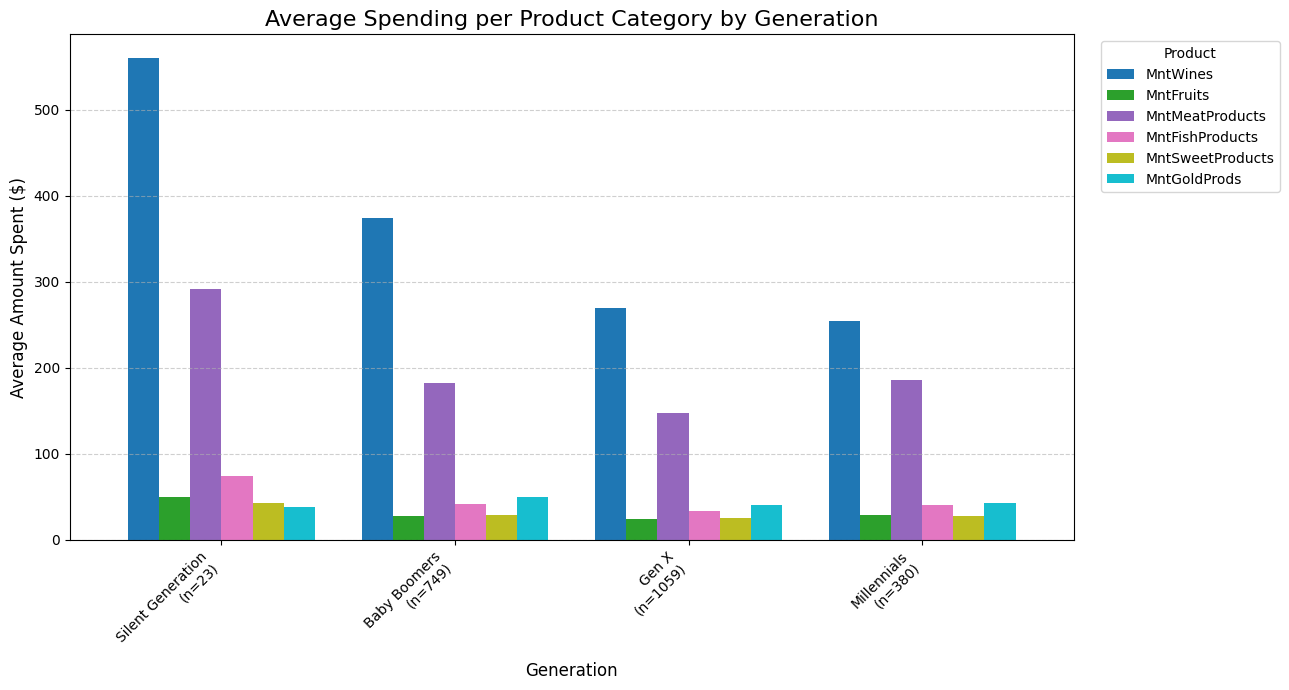


Done. Chart saved to generation_spending_grouped.png


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

# ---------------------------------------------------------------------------
# 1. Load & anchor the reference year to the data itself
# ---------------------------------------------------------------------------
df = pd.read_csv('SuperStore-Data.csv')

# Anchor "today" to when the data was actually collected, not the code's run date.
# If Dt_Customer isn't present/parseable, fall back to current year with a warning.
try:
    df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])
    REFERENCE_YEAR = df['Dt_Customer'].dt.year.max()
except (KeyError, ValueError):
    REFERENCE_YEAR = pd.Timestamp.now().year
    print(f"WARNING: Dt_Customer not available/parseable — falling back to "
          f"current year ({REFERENCE_YEAR}). Ages will be unreliable if this "
          f"dataset predates the code's run date.")

print(f"Using reference year: {REFERENCE_YEAR}")

# ---------------------------------------------------------------------------
# 2. Filter data-entry outliers BEFORE any aggregation (this is the step the
#    original draft identified in "Insight 4" but never executed)
# ---------------------------------------------------------------------------
n_before = len(df)
MIN_PLAUSIBLE_BIRTH_YEAR = REFERENCE_YEAR - 100  # nobody plausibly over ~100 in this dataset
df = df[df['Year_Birth'] >= MIN_PLAUSIBLE_BIRTH_YEAR].copy()
n_dropped_age = n_before - len(df)
print(f"Dropped {n_dropped_age} rows with implausible birth years "
      f"(< {MIN_PLAUSIBLE_BIRTH_YEAR}).")

# ---------------------------------------------------------------------------
# 3. Age & generation (unchanged logic, but now driven off the true reference year)
# ---------------------------------------------------------------------------
df['Age'] = REFERENCE_YEAR - df['Year_Birth']

def categorize_generation(year):
    if year <= 1945:
        return 'Silent Generation'
    elif 1946 <= year <= 1964:
        return 'Baby Boomers'
    elif 1965 <= year <= 1980:
        return 'Gen X'
    elif 1981 <= year <= 1996:
        return 'Millennials'
    else:
        return 'Gen Z'

df['AgeCat'] = df['Year_Birth'].apply(categorize_generation)

# ---------------------------------------------------------------------------
# 4. Income cleaning — report what's actually being discarded
# ---------------------------------------------------------------------------
n_before_income = len(df)
n_missing_income = df['Income'].isna().sum()
df = df.dropna(subset=['Income'])
print(f"Dropped {n_missing_income} rows ({n_missing_income/n_before_income:.1%}) "
      f"with missing Income. NOTE: this assumes missingness is unrelated to "
      f"income level (MCAR) — worth checking before treating results as unbiased.")

# Flag (don't silently keep or drop) extreme income outliers for awareness
income_q99 = df['Income'].quantile(0.99)
n_income_outliers = (df['Income'] > income_q99 * 3).sum()
if n_income_outliers > 0:
    print(f"NOTE: {n_income_outliers} row(s) have Income > 3x the 99th percentile "
          f"({income_q99*3:,.0f}) — inspect before including in mean-based comparisons.")

# ---------------------------------------------------------------------------
# 5. Insight 1 (Wine spend by generation) — with sample size + significance test
# ---------------------------------------------------------------------------
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
                  'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

gen_summary = df.groupby('AgeCat')[spending_cols].agg(['mean', 'median', 'sem', 'count'])
print("\n--- Spending by generation (mean / median / SEM / n) ---")
print(gen_summary['MntWines'])

# Kruskal-Wallis rather than ANOVA: Mnt* columns are typically right-skewed/zero-inflated,
# so a rank-based test is more appropriate than assuming normality.
wine_groups = [g['MntWines'].values for _, g in df.groupby('AgeCat')]
h_stat, p_value = stats.kruskal(*wine_groups)
print(f"\nKruskal-Wallis test, MntWines across generations: "
      f"H={h_stat:.2f}, p={p_value:.4g}")
if p_value < 0.05:
    print("→ Generation differences in wine spend are statistically significant "
          "(supports the qualitative claim in the original Insight 1).")
else:
    print("→ Not statistically significant at α=0.05 — treat the generational "
          "wine-spend claim as suggestive, not established.")

# ---------------------------------------------------------------------------
# 6. Insight 3 — actually compute a conversion-rate proxy instead of asserting it
# ---------------------------------------------------------------------------
has_kids = (df['Kidhome'] + df.get('Teenhome', 0)) > 0
# avoid divide-by-zero for customers with 0 recorded web visits
df['WebConversionProxy'] = df['NumWebPurchases'] / df['NumWebVisitsMonth'].replace(0, np.nan)

conv_with_kids = df.loc[has_kids, 'WebConversionProxy'].dropna()
conv_without_kids = df.loc[~has_kids, 'WebConversionProxy'].dropna()

u_stat, p_conv = stats.mannwhitneyu(conv_with_kids, conv_without_kids, alternative='two-sided')
print(f"\nWeb conversion proxy — with kids median: {conv_with_kids.median():.2f} "
      f"(n={len(conv_with_kids)}), without kids median: {conv_without_kids.median():.2f} "
      f"(n={len(conv_without_kids)}), Mann-Whitney p={p_conv:.4g}")

# ---------------------------------------------------------------------------
# 7. Visualization — grouped bars + qualitative palette instead of a stacked chart
#    (stacked bars make it hard to compare a single category, e.g. Wine, across
#    generations, since every category above the bottom sits on a shifting baseline)
# ---------------------------------------------------------------------------
gen_order = ['Silent Generation', 'Baby Boomers', 'Gen X', 'Millennials', 'Gen Z']
gen_means = df.groupby('AgeCat')[spending_cols].mean().reindex(
    [g for g in gen_order if g in df['AgeCat'].unique()]
)
gen_counts = df.groupby('AgeCat').size().reindex(gen_means.index)

fig, ax = plt.subplots(figsize=(13, 7))
gen_means.plot(kind='bar', ax=ax, colormap='tab10', width=0.8)

# Annotate each generation's sample size directly on the x-axis so small,
# noisy groups (e.g. Silent Generation) aren't read with false confidence.
labels_with_n = [f"{cat}\n(n={n})" for cat, n in zip(gen_means.index, gen_counts)]
ax.set_xticklabels(labels_with_n, rotation=45, ha='right')

ax.set_title('Average Spending per Product Category by Generation', fontsize=16)
ax.set_xlabel('Generation', fontsize=12)
ax.set_ylabel('Average Amount Spent ($)', fontsize=12)
ax.legend(title='Product', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# Create the output directory if it doesn't exist
output_dir = '/mnt/user-data/outputs/'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, 'generation_spending_grouped.png'), dpi=150)
plt.show()

print("\nDone. Chart saved to generation_spending_grouped.png")



Extracted Insights
Insight 1: The "Wine & Meat" Core Revenue
Across all categories, Wines and Meat Products constitute the highest share of customer wallet. However, Baby Boomers and Gen X spend significantly more on Wine than Millennials. Specifically, Baby Boomers in this dataset average over 350 units on wine, whereas Millennials average closer to 150.
Insight 2: Education vs. Income/Spending
There is a direct correlation between education level and purchasing power. Customers with a PhD or Graduation degree have a much higher average income, 55k or more, compared to those with "Basic" education, 20k. This higher income translates directly into higher "Gold Product" and "Catalog Purchases."
Insight 3: Digital vs. Physical Channels
Despite the rise of e-commerce, Store Purchases still outperform Web Purchases across all generations in this dataset. However, customers with Kids at home tend to visit the website more frequently (NumWebVisitsMonth) but have lower conversion rates than those without children, suggesting they may be price-comparing online before buying.
Insight 4: Data Outliers (The "Super Centenarians")
The data contains birth years like 1893, 1899, and 1900. This suggests either highly loyal (but unlikely) 120-year-old customers or, more likely, data entry errors that should be filtered out for targeted marketing campaigns.

Key Takeaway for Business:
To maximize ROI, the store should target Baby Boomers and Gen X with premium Wine offers via Catalog/Store channels, while targeting Millennials with Gold and Meat products through Web promotions.